In [1]:
import pandas as pd
import numpy as np

# 1. Load both datasets
df_train_raw = pd.read_csv('/Users/mac/Desktop/IITK/Academics/SUMMER SEM 2025-26/ECO723/GROUP PROJECT/archive/fraudTrain.csv')
df_test_raw = pd.read_csv('/Users/mac/Desktop/IITK/Academics/SUMMER SEM 2025-26/ECO723/GROUP PROJECT/archive/fraudTest.csv')

# 2. Tag the data so you can easily separate it later
df_train_raw['is_test_set'] = 0
df_test_raw['is_test_set'] = 1

# 3. Concatenate into one massive dataframe for feature engineering
df = pd.concat([df_train_raw, df_test_raw], ignore_index=True)

# 4. Convert time and sort strictly by card number and time
df['trans_date_trans_time'] = pd.to_datetime(df['unix_time'], unit='s')
df = df.sort_values(by=['cc_num', 'trans_date_trans_time']).reset_index(drop=True)

print(f"Combined Dataset Shape: {df.shape}")

Combined Dataset Shape: (1852394, 24)


example 1 (sort by last 5 transactions)

In [2]:
# Rolling mean of the 'amt' column over a 5-transaction window
df['HOBA_amt_mean_5tx'] = df.groupby('cc_num')['amt'].transform(
    lambda x: x.rolling(window=5, min_periods=1).mean()
)

# You would repeat this pattern for max, sum, and standard deviation.

example 2 (sort by past 1 day transactions)

In [3]:
# Set the index temporarily to execute the time-based rolling window
df_time_indexed = df.set_index('trans_date_trans_time')

# Calculate the rolling sum over '1D' (1 Day)
df['HOBA_amt_sum_1d'] = df_time_indexed.groupby('cc_num')['amt'].transform(
    lambda x: x.rolling('1D').sum()
).values

In [4]:
# Rolling max amount for the past 7 days, isolated by BOTH cardholder and transaction category
df['HOBA_amt_max_7d_by_category'] = df_time_indexed.groupby(['cc_num', 'category'])['amt'].transform(
    lambda x: x.rolling('7D').max()
).values

In [5]:
df_time_indexed = df.set_index('trans_date_trans_time')

In [6]:
def haversine_vectorized(lat1, lon1, lat2, lon2):
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1 
    dlon = lon2 - lon1 
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a)) 
    r = 6371 # Radius of earth in kilometers
    
    return c * r

# Apply the function to create a base distance metric for the current transaction
df['distance_to_merchant_km'] = haversine_vectorized(
    df['lat'], df['long'], 
    df['merch_lat'], df['merch_long']
)

In [7]:
df_time_indexed = df.set_index('trans_date_trans_time').sort_index()

In [8]:
# Assuming df_time_indexed is your dataframe with trans_datetime as the index
# Calculate the maximum distance to a merchant over the past 3 days for each cardholder
df['HOBA_dist_max_3d'] = df_time_indexed.groupby('cc_num')['distance_to_merchant_km'].transform(lambda x: x.rolling('3D').max()).values

# Calculate the average distance to merchants over the past 5 transactions
df['HOBA_dist_mean_5tx'] = df.groupby('cc_num')['distance_to_merchant_km'].transform(lambda x: x.rolling(window=5, min_periods=1).mean())

In [9]:
from sklearn.preprocessing import MinMaxScaler

# 1. Split the data back into train and test using the tag
df_train = df[df['is_test_set'] == 0].copy()
df_test = df[df['is_test_set'] == 1].copy()

# 2. Define columns that the model MUST NOT see (including our temporary tag)
columns_to_drop = [
    'is_fraud', 'is_test_set', 'cc_num', 'trans_num', 'merchant', 'category', 
    'first', 'last', 'gender', 'street', 'city', 'state', 'job', 'dob',
    'trans_date_trans_time', 'unix_time', 'lat', 'long', 'merch_lat', 'merch_long',
    'Unnamed: 0'
]

# 3. Dynamically extract all numerical feature columns
feature_columns = [col for col in df_train.columns if col not in columns_to_drop]

# 4. Initialize and fit the scaler ONLY on the training data
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(df_train[feature_columns])

# 5. Transform the test data
X_test_scaled = scaler.transform(df_test[feature_columns])

# 6. Extract the target labels
y_train = df_train['is_fraud'].values
y_test = df_test['is_fraud'].values

print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")

Training features shape: (1296675, 9)
Testing features shape: (555719, 9)


In [10]:
from sklearn.metrics import roc_curve, roc_auc_score, f1_score, precision_score, recall_score
import numpy as np

def evaluate_fraud_business_metrics(y_true, y_pred_proba, max_fpr):
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    
    # Find the index of the largest FPR that is still under our max_fpr limit
    idx = np.where(fpr <= max_fpr)[0][-1]
    chosen_threshold = thresholds[idx]
    
    # Convert probabilities to binary predictions based on this new threshold
    y_pred_adj = (y_pred_proba >= chosen_threshold).astype(int)
    
    # Calculate final metrics
    f1 = f1_score(y_true, y_pred_adj)
    precision = precision_score(y_true, y_pred_adj)
    recall = recall_score(y_true, y_pred_adj)
    actual_fpr = fpr[idx]
    
    print(f"--- Metrics at Max FPR {max_fpr*100}% (Threshold: {chosen_threshold:.4f}) ---")
    print(f"Actual FPR: {actual_fpr*100:.4f}%")
    print(f"Recall (Fraud Caught):   {recall*100:.2f}%")
    print(f"Precision (True Alarms): {precision*100:.2f}%")
    print(f"F1-Score: {f1:.4f}\n")

In [11]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model (limited depth and estimators to keep training time reasonable for a baseline)
print("Initializing and training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=50, max_depth=15, class_weight='balanced', random_state=42, n_jobs=-1)

# Fit the model
rf_model.fit(X_train_scaled, y_train)
print("Training complete.")

# Predict probabilities on the testing set
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# 1. Overall AUC Score
auc_score = roc_auc_score(y_test, y_pred_proba_rf)
print(f"\nOverall ROC AUC Score: {auc_score:.4f}\n")

# 2. Evaluate at strict business tolerances (1% and 3% FPR)
evaluate_fraud_business_metrics(y_test, y_pred_proba_rf, max_fpr=0.01)
evaluate_fraud_business_metrics(y_test, y_pred_proba_rf, max_fpr=0.03)

Initializing and training Random Forest...
Training complete.

Overall ROC AUC Score: 0.9831

--- Metrics at Max FPR 1.0% (Threshold: 0.5107) ---
Actual FPR: 0.9715%
Recall (Fraud Caught):   86.06%
Precision (True Alarms): 25.55%
F1-Score: 0.3941

--- Metrics at Max FPR 3.0% (Threshold: 0.1719) ---
Actual FPR: 2.9662%
Recall (Fraud Caught):   92.63%
Precision (True Alarms): 10.79%
F1-Score: 0.1934



In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RBM(nn.Module):
    def __init__(self, visible_dim, hidden_dim):
        super(RBM, self).__init__()
        # Initialize weights and biases
        self.W = nn.Parameter(torch.randn(hidden_dim, visible_dim) * 0.01)
        self.h_bias = nn.Parameter(torch.zeros(hidden_dim))
        self.v_bias = nn.Parameter(torch.zeros(visible_dim))

    def sample_h(self, v):
        # Probability of hidden unit being active given visible units
        h_prob = torch.sigmoid(F.linear(v, self.W, self.h_bias))
        h_sample = torch.bernoulli(h_prob)
        return h_prob, h_sample

    def sample_v(self, h):
        # Probability of visible unit being active given hidden units
        v_prob = torch.sigmoid(F.linear(h, self.W.t(), self.v_bias))
        v_sample = torch.bernoulli(v_prob)
        return v_prob, v_sample

    def contrastive_divergence(self, v_pos, lr=0.01):
        # --- Positive Phase ---
        h_pos_prob, h_pos_sample = self.sample_h(v_pos)

        # --- Negative Phase (Gibbs Sampling) ---
        v_neg_prob, v_neg_sample = self.sample_v(h_pos_sample)
        h_neg_prob, _ = self.sample_h(v_neg_prob)

        # --- Calculate Gradients ---
        pos_grad = torch.matmul(h_pos_prob.t(), v_pos)
        neg_grad = torch.matmul(h_neg_prob.t(), v_neg_prob)

        # --- Update Weights & Biases ---
        batch_size = v_pos.size(0)
        self.W.data += lr * (pos_grad - neg_grad) / batch_size
        self.v_bias.data += lr * torch.mean(v_pos - v_neg_prob, dim=0)
        self.h_bias.data += lr * torch.mean(h_pos_prob - h_neg_prob, dim=0)
        
        # Calculate reconstruction error for monitoring
        error = torch.mean((v_pos - v_neg_prob)**2)
        return error.item()

In [13]:
from torch.utils.data import DataLoader, TensorDataset

# 1. Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.LongTensor(y_train)

X_test_tensor = torch.FloatTensor(X_test_scaled)

# 2. Create a DataLoader for batch processing
batch_size = 256
train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=batch_size, shuffle=True)

# 3. Initialize the first RBM Layer
input_features = X_train_scaled.shape[1]
hidden_units_layer_1 = 64  # We compress the input features to extract core patterns

rbm_layer_1 = RBM(visible_dim=input_features, hidden_dim=hidden_units_layer_1)

# 4. Train the RBM using Contrastive Divergence
epochs = 10
learning_rate = 0.01

print("Starting unsupervised RBM pre-training...")
for epoch in range(epochs):
    epoch_error = 0
    for batch in train_loader:
        v_batch = batch[0]
        # Update weights and get reconstruction error
        error = rbm_layer_1.contrastive_divergence(v_batch, lr=learning_rate)
        epoch_error += error
        
    avg_error = epoch_error / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} | Reconstruction Error: {avg_error:.4f}")
    
print("Layer 1 Pre-training Complete.")

Starting unsupervised RBM pre-training...
Epoch 1/10 | Reconstruction Error: 0.0162
Epoch 2/10 | Reconstruction Error: 0.0158
Epoch 3/10 | Reconstruction Error: 0.0162
Epoch 4/10 | Reconstruction Error: 0.0172
Epoch 5/10 | Reconstruction Error: 0.0182
Epoch 6/10 | Reconstruction Error: 0.0190
Epoch 7/10 | Reconstruction Error: 0.0197
Epoch 8/10 | Reconstruction Error: 0.0202
Epoch 9/10 | Reconstruction Error: 0.0205
Epoch 10/10 | Reconstruction Error: 0.0207
Layer 1 Pre-training Complete.


In [14]:
import torch.optim as optim

class SupervisedDBN(nn.Module):
    def __init__(self, pretrained_rbm):
        super(SupervisedDBN, self).__init__()
        self.hidden_layer = nn.Linear(pretrained_rbm.W.shape[1], pretrained_rbm.W.shape[0])
        self.hidden_layer.weight.data = pretrained_rbm.W.clone()
        self.hidden_layer.bias.data = pretrained_rbm.h_bias.clone()
        self.output_layer = nn.Linear(pretrained_rbm.W.shape[0], 1)
        
    def forward(self, x):
        x = torch.sigmoid(self.hidden_layer(x))
        # REMOVED the final torch.sigmoid() here because BCEWithLogitsLoss handles it
        x = self.output_layer(x)
        return x

dbn_model = SupervisedDBN(rbm_layer_1)

# --- Updated Training Loop ---

# Calculate the exact imbalance weight (Negative samples / Positive samples)
pos_weight_value = (len(y_train) - sum(y_train)) / sum(y_train)
class_weight = torch.FloatTensor([pos_weight_value])

# Use BCEWithLogitsLoss and apply the weight
criterion = nn.BCEWithLogitsLoss(pos_weight=class_weight)
optimizer = optim.Adam(dbn_model.parameters(), lr=0.001) 

train_loader_supervised = DataLoader(TensorDataset(X_train_tensor, y_train_tensor.float()), batch_size=256, shuffle=True)
fine_tune_epochs = 15

print("Starting supervised fine-tuning with weighted loss...")
dbn_model.train()

for epoch in range(fine_tune_epochs):
    epoch_loss = 0
    for batch_features, batch_labels in train_loader_supervised:
        optimizer.zero_grad()
        outputs = dbn_model(batch_features).squeeze()
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    print(f"Epoch {epoch+1}/{fine_tune_epochs} | Classification Loss: {epoch_loss/len(train_loader_supervised):.4f}")

Starting supervised fine-tuning with weighted loss...
Epoch 1/15 | Classification Loss: 0.9502
Epoch 2/15 | Classification Loss: 0.5303
Epoch 3/15 | Classification Loss: 0.5011
Epoch 4/15 | Classification Loss: 0.4960
Epoch 5/15 | Classification Loss: 0.4935
Epoch 6/15 | Classification Loss: 0.4894
Epoch 7/15 | Classification Loss: 0.4868
Epoch 8/15 | Classification Loss: 0.4863
Epoch 9/15 | Classification Loss: 0.4844
Epoch 10/15 | Classification Loss: 0.4830
Epoch 11/15 | Classification Loss: 0.4814
Epoch 12/15 | Classification Loss: 0.4803
Epoch 13/15 | Classification Loss: 0.4795
Epoch 14/15 | Classification Loss: 0.4790
Epoch 15/15 | Classification Loss: 0.4773


In [15]:
dbn_model.eval()

with torch.no_grad():
    raw_logits = dbn_model(X_test_tensor).squeeze()
    # Apply sigmoid to convert logits back to probabilities (0 to 1)
    y_pred_proba_dbn_tensor = torch.sigmoid(raw_logits)
    
y_pred_proba_dbn = y_pred_proba_dbn_tensor.numpy()

auc_score_dbn = roc_auc_score(y_test, y_pred_proba_dbn)
print("\n--- Deep Belief Network (DBN) Performance ---")
print(f"Overall ROC AUC Score: {auc_score_dbn:.4f}\n")

evaluate_fraud_business_metrics(y_test, y_pred_proba_dbn, max_fpr=0.01)
evaluate_fraud_business_metrics(y_test, y_pred_proba_dbn, max_fpr=0.03)


--- Deep Belief Network (DBN) Performance ---
Overall ROC AUC Score: 0.9515

--- Metrics at Max FPR 1.0% (Threshold: 0.9120) ---
Actual FPR: 0.9972%
Recall (Fraud Caught):   75.15%
Precision (True Alarms): 22.60%
F1-Score: 0.3475

--- Metrics at Max FPR 3.0% (Threshold: 0.5698) ---
Actual FPR: 2.9920%
Recall (Fraud Caught):   83.82%
Precision (True Alarms): 9.79%
F1-Score: 0.1754



# RBM LAYER 2

In [16]:
# 1. Extract the hidden representations from the first RBM
print("Extracting hidden features from Layer 1...")
with torch.no_grad():
    h1_features, _ = rbm_layer_1.sample_h(X_train_tensor)

# Create a DataLoader for the hidden features
train_loader_h1 = DataLoader(TensorDataset(h1_features), batch_size=batch_size, shuffle=True)

# 2. Initialize the second RBM Layer
hidden_units_layer_2 = 32  # Further compressing the 64-dimensional features down to 32
rbm_layer_2 = RBM(visible_dim=hidden_units_layer_1, hidden_dim=hidden_units_layer_2)

# 3. Train RBM Layer 2
print("Starting unsupervised RBM Layer 2 pre-training...")
for epoch in range(epochs):
    epoch_error = 0
    for batch in train_loader_h1:
        v_batch = batch[0]
        error = rbm_layer_2.contrastive_divergence(v_batch, lr=learning_rate)
        epoch_error += error
        
    avg_error = epoch_error / len(train_loader_h1)
    print(f"Epoch {epoch+1}/{epochs} | Reconstruction Error: {avg_error:.4f}")
    
print("Layer 2 Pre-training Complete.")

Extracting hidden features from Layer 1...
Starting unsupervised RBM Layer 2 pre-training...
Epoch 1/10 | Reconstruction Error: 0.0008
Epoch 2/10 | Reconstruction Error: 0.0008
Epoch 3/10 | Reconstruction Error: 0.0008
Epoch 4/10 | Reconstruction Error: 0.0008
Epoch 5/10 | Reconstruction Error: 0.0008
Epoch 6/10 | Reconstruction Error: 0.0009
Epoch 7/10 | Reconstruction Error: 0.0009
Epoch 8/10 | Reconstruction Error: 0.0010
Epoch 9/10 | Reconstruction Error: 0.0011
Epoch 10/10 | Reconstruction Error: 0.0011
Layer 2 Pre-training Complete.


In [17]:
class DeepSupervisedDBN(nn.Module):
    def __init__(self, rbm1, rbm2):
        super(DeepSupervisedDBN, self).__init__()
        
        # Layer 1
        self.layer1 = nn.Linear(rbm1.W.shape[1], rbm1.W.shape[0])
        self.layer1.weight.data = rbm1.W.clone()
        self.layer1.bias.data = rbm1.h_bias.clone()
        
        # Layer 2
        self.layer2 = nn.Linear(rbm2.W.shape[1], rbm2.W.shape[0])
        self.layer2.weight.data = rbm2.W.clone()
        self.layer2.bias.data = rbm2.h_bias.clone()
        
        # Final Classification Layer
        self.output_layer = nn.Linear(rbm2.W.shape[0], 1)
        
    def forward(self, x):
        x = torch.sigmoid(self.layer1(x))
        x = torch.sigmoid(self.layer2(x))
        x = self.output_layer(x) # Raw logits for BCEWithLogitsLoss
        return x

deep_dbn_model = DeepSupervisedDBN(rbm_layer_1, rbm_layer_2)
print("True Deep DBN architecture constructed.")

True Deep DBN architecture constructed.


In [18]:
# 1. Setup Optimizer and Loss
optimizer_deep = optim.Adam(deep_dbn_model.parameters(), lr=0.001) 
criterion_deep = nn.BCEWithLogitsLoss(pos_weight=class_weight)

print("Starting deep supervised fine-tuning...")
deep_dbn_model.train()

for epoch in range(fine_tune_epochs):
    epoch_loss = 0
    for batch_features, batch_labels in train_loader_supervised:
        optimizer_deep.zero_grad()
        outputs = deep_dbn_model(batch_features).squeeze()
        loss = criterion_deep(outputs, batch_labels)
        loss.backward()
        optimizer_deep.step()
        epoch_loss += loss.item()
        
    print(f"Epoch {epoch+1}/{fine_tune_epochs} | Classification Loss: {epoch_loss/len(train_loader_supervised):.4f}")

# 2. Evaluation
deep_dbn_model.eval()
with torch.no_grad():
    raw_logits_deep = deep_dbn_model(X_test_tensor).squeeze()
    y_pred_proba_deep = torch.sigmoid(raw_logits_deep).numpy()

auc_score_deep = roc_auc_score(y_test, y_pred_proba_deep)
print("\n--- Deep Belief Network (2-Layer) Performance ---")
print(f"Overall ROC AUC Score: {auc_score_deep:.4f}\n")

evaluate_fraud_business_metrics(y_test, y_pred_proba_deep, max_fpr=0.01)
evaluate_fraud_business_metrics(y_test, y_pred_proba_deep, max_fpr=0.03)

Starting deep supervised fine-tuning...
Epoch 1/15 | Classification Loss: 1.0137
Epoch 2/15 | Classification Loss: 0.5234
Epoch 3/15 | Classification Loss: 0.5066
Epoch 4/15 | Classification Loss: 0.4991
Epoch 5/15 | Classification Loss: 0.4937
Epoch 6/15 | Classification Loss: 0.4878
Epoch 7/15 | Classification Loss: 0.4834
Epoch 8/15 | Classification Loss: 0.4835
Epoch 9/15 | Classification Loss: 0.4774
Epoch 10/15 | Classification Loss: 0.4756
Epoch 11/15 | Classification Loss: 0.4723
Epoch 12/15 | Classification Loss: 0.4702
Epoch 13/15 | Classification Loss: 0.4707
Epoch 14/15 | Classification Loss: 0.4695
Epoch 15/15 | Classification Loss: 0.4674

--- Deep Belief Network (2-Layer) Performance ---
Overall ROC AUC Score: 0.9514

--- Metrics at Max FPR 1.0% (Threshold: 0.9269) ---
Actual FPR: 0.9930%
Recall (Fraud Caught):   75.15%
Precision (True Alarms): 22.68%
F1-Score: 0.3484

--- Metrics at Max FPR 3.0% (Threshold: 0.6384) ---
Actual FPR: 2.9949%
Recall (Fraud Caught):   83.87%

In [19]:
# Assuming df is your chronologically sorted, combined train/test dataframe
df_time_indexed = df.set_index('trans_date_trans_time').sort_index()

# 1. Define the HOBA Methodology Parameters
time_windows = ['1D', '3D', '7D', '15D']
categories = df['category'].unique()

print("Expanding HOBA Feature Matrix...")

# 2. Automate the Transaction Aggregation Strategy
for window in time_windows:
    # A. Time-based general aggregations
    df[f'HOBA_amt_sum_{window}'] = df_time_indexed.groupby('cc_num')['amt'].transform(lambda x: x.rolling(window).sum()).values
    df[f'HOBA_amt_max_{window}'] = df_time_indexed.groupby('cc_num')['amt'].transform(lambda x: x.rolling(window).max()).values
    
    # B. Category-specific aggregations (Homogeneity-Oriented)
    for cat in categories:
        # Create a temporary column that only has amounts for this specific category (0 otherwise)
        df_time_indexed['temp_amt'] = np.where(df_time_indexed['category'] == cat, df_time_indexed['amt'], 0)
        
        # Calculate rolling sum for this specific category over the time window
        df[f'HOBA_amt_sum_{cat}_{window}'] = df_time_indexed.groupby('cc_num')['temp_amt'].transform(
            lambda x: x.rolling(window).sum()
        ).values

# 3. Clean up temporary columns
df_time_indexed.drop(columns=['temp_amt'], inplace=True, errors='ignore')

print(f"Feature expansion complete. New dataset shape: {df.shape}")

Expanding HOBA Feature Matrix...
Feature expansion complete. New dataset shape: (1852394, 94)


In [20]:
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# --- 1. Split, Isolate, and Scale the 94 Features ---
df_train = df[df['is_test_set'] == 0].copy()
df_test = df[df['is_test_set'] == 1].copy()

columns_to_drop = [
    'is_fraud', 'is_test_set', 'cc_num', 'trans_num', 'merchant', 'category', 
    'first', 'last', 'gender', 'street', 'city', 'state', 'job', 'dob',
    'trans_date_trans_time', 'unix_time', 'lat', 'long', 'merch_lat', 'merch_long',
    'Unnamed: 0'
]

feature_columns = [col for col in df_train.columns if col not in columns_to_drop]
print(f"Training on {len(feature_columns)} HOBA features...")

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(df_train[feature_columns])
X_test_scaled = scaler.transform(df_test[feature_columns])

X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=256, shuffle=True)

# --- 2. Unsupervised Pre-Training (Layer 1 & 2) ---
input_features = len(feature_columns)
rbm_layer_1 = RBM(visible_dim=input_features, hidden_dim=64)

print("\n[Phase 1] Pre-training RBM Layer 1...")
for epoch in range(10):
    for batch in train_loader:
        rbm_layer_1.contrastive_divergence(batch[0], lr=0.01)

print("[Phase 2] Extracting hidden features and pre-training RBM Layer 2...")
with torch.no_grad():
    h1_features, _ = rbm_layer_1.sample_h(X_train_tensor)
train_loader_h1 = DataLoader(TensorDataset(h1_features), batch_size=256, shuffle=True)

rbm_layer_2 = RBM(visible_dim=64, hidden_dim=32)
for epoch in range(10):
    for batch in train_loader_h1:
        rbm_layer_2.contrastive_divergence(batch[0], lr=0.01)

# --- 3. Deep Supervised Fine-Tuning ---
print("\n[Phase 3] Supervised Fine-Tuning of the Deep Architecture...")
deep_dbn_model = DeepSupervisedDBN(rbm_layer_1, rbm_layer_2)

# Applying the same class weight logic as before
pos_weight_value = (len(y_train) - sum(y_train)) / sum(y_train)
class_weight = torch.FloatTensor([pos_weight_value])

optimizer_deep = optim.Adam(deep_dbn_model.parameters(), lr=0.001) 
criterion_deep = nn.BCEWithLogitsLoss(pos_weight=class_weight)
train_loader_supervised = DataLoader(TensorDataset(X_train_tensor, torch.LongTensor(y_train).float()), batch_size=256, shuffle=True)

deep_dbn_model.train()
for epoch in range(15):
    for batch_features, batch_labels in train_loader_supervised:
        optimizer_deep.zero_grad()
        outputs = deep_dbn_model(batch_features).squeeze()
        loss = criterion_deep(outputs, batch_labels)
        loss.backward()
        optimizer_deep.step()

# --- 4. Final Evaluation ---
deep_dbn_model.eval()
with torch.no_grad():
    raw_logits_deep = deep_dbn_model(X_test_tensor).squeeze()
    y_pred_proba_deep = torch.sigmoid(raw_logits_deep).numpy()

auc_score_deep = roc_auc_score(y_test, y_pred_proba_deep)
print("\n=======================================================")
print("          FINAL DEEP BELIEF NETWORK PERFORMANCE        ")
print("=======================================================")
print(f"Overall ROC AUC Score: {auc_score_deep:.4f}\n")

evaluate_fraud_business_metrics(y_test, y_pred_proba_deep, max_fpr=0.01)
evaluate_fraud_business_metrics(y_test, y_pred_proba_deep, max_fpr=0.03)

Training on 73 HOBA features...

[Phase 1] Pre-training RBM Layer 1...
[Phase 2] Extracting hidden features and pre-training RBM Layer 2...

[Phase 3] Supervised Fine-Tuning of the Deep Architecture...

          FINAL DEEP BELIEF NETWORK PERFORMANCE        
Overall ROC AUC Score: 0.9517

--- Metrics at Max FPR 1.0% (Threshold: 0.9625) ---
Actual FPR: 0.9979%
Recall (Fraud Caught):   75.62%
Precision (True Alarms): 22.70%
F1-Score: 0.3492

--- Metrics at Max FPR 3.0% (Threshold: 0.8037) ---
Actual FPR: 2.9853%
Recall (Fraud Caught):   83.92%
Precision (True Alarms): 9.82%
F1-Score: 0.1759



In [21]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class FraudCNN(nn.Module):
    def __init__(self, num_features):
        super(FraudCNN, self).__init__()
        # 1D Convolution: input channels=1, output channels=16, kernel_size=3
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2)
        
        # Calculate the flattened dimension after pooling
        self.flattened_dim = 16 * (num_features // 2)
        
        # Fully connected classification layers
        self.fc1 = nn.Linear(self.flattened_dim, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        # CNN expects input shape: (batch_size, channels, features)
        # We add a channel dimension to our 1D features
        x = x.unsqueeze(1) 
        
        x = self.pool(F.relu(self.conv1(x)))
        x = x.view(-1, self.flattened_dim) # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x) # Raw logits
        return x

print("CNN Architecture Initialized.")

CNN Architecture Initialized.


In [22]:
class ElmanRNN(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super(ElmanRNN, self).__init__()
        # PyTorch's nn.RNN is the standard Elman network architecture
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        
        # Final classification layer
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # RNN expects input shape: (batch_size, sequence_length, features)
        # We treat the HOBA feature vector as a sequence of 1 time-step containing all behavioral data
        x = x.unsqueeze(1)
        
        # Out contains the output features from the last layer of the RNN
        out, hidden = self.rnn(x)
        
        # Take the output of the final time step
        out = out[:, -1, :]
        out = self.fc(out) # Raw logits
        return out

print("Elman RNN Architecture Initialized.")

Elman RNN Architecture Initialized.


In [23]:
# --- Setup ---
num_features = X_train_tensor.shape[1]
cnn_model = FraudCNN(num_features)
rnn_model = ElmanRNN(num_features)

# Use the class weight calculated earlier
criterion = nn.BCEWithLogitsLoss(pos_weight=class_weight)
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=0.001)
optimizer_rnn = optim.Adam(rnn_model.parameters(), lr=0.001)

epochs = 15

# --- Train CNN ---
print("\n--- Training Convolutional Neural Network (CNN) ---")
cnn_model.train()
for epoch in range(epochs):
    epoch_loss = 0
    for batch_features, batch_labels in train_loader_supervised:
        optimizer_cnn.zero_grad()
        outputs = cnn_model(batch_features).squeeze()
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer_cnn.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss/len(train_loader_supervised):.4f}")

# --- Train RNN ---
print("\n--- Training Elman Recurrent Neural Network (RNN) ---")
rnn_model.train()
for epoch in range(epochs):
    epoch_loss = 0
    for batch_features, batch_labels in train_loader_supervised:
        optimizer_rnn.zero_grad()
        outputs = rnn_model(batch_features).squeeze()
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer_rnn.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss/len(train_loader_supervised):.4f}")

# --- Evaluate Both Models ---
cnn_model.eval()
rnn_model.eval()

with torch.no_grad():
    y_pred_proba_cnn = torch.sigmoid(cnn_model(X_test_tensor).squeeze()).numpy()
    y_pred_proba_rnn = torch.sigmoid(rnn_model(X_test_tensor).squeeze()).numpy()

print("\n=======================================================")
print("             CNN PERFORMANCE BENCHMARK                 ")
print("=======================================================")
print(f"Overall ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_cnn):.4f}\n")
evaluate_fraud_business_metrics(y_test, y_pred_proba_cnn, max_fpr=0.01)

print("\n=======================================================")
print("             RNN PERFORMANCE BENCHMARK                 ")
print("=======================================================")
print(f"Overall ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_rnn):.4f}\n")
evaluate_fraud_business_metrics(y_test, y_pred_proba_rnn, max_fpr=0.01)


--- Training Convolutional Neural Network (CNN) ---
Epoch 1/15 | Loss: 1.0505
Epoch 2/15 | Loss: 0.6184
Epoch 3/15 | Loss: 0.5576
Epoch 4/15 | Loss: 0.5278
Epoch 5/15 | Loss: 0.5045
Epoch 6/15 | Loss: 0.4858
Epoch 7/15 | Loss: 0.4771
Epoch 8/15 | Loss: 0.4772
Epoch 9/15 | Loss: 0.4731
Epoch 10/15 | Loss: 0.4699
Epoch 11/15 | Loss: 0.4678
Epoch 12/15 | Loss: 0.4681
Epoch 13/15 | Loss: 0.4656
Epoch 14/15 | Loss: 0.4630
Epoch 15/15 | Loss: 0.4623

--- Training Elman Recurrent Neural Network (RNN) ---
Epoch 1/15 | Loss: 0.6476
Epoch 2/15 | Loss: 0.5126
Epoch 3/15 | Loss: 0.5043
Epoch 4/15 | Loss: 0.4986
Epoch 5/15 | Loss: 0.4964
Epoch 6/15 | Loss: 0.4930
Epoch 7/15 | Loss: 0.4921
Epoch 8/15 | Loss: 0.4906
Epoch 9/15 | Loss: 0.4874
Epoch 10/15 | Loss: 0.4849
Epoch 11/15 | Loss: 0.4849
Epoch 12/15 | Loss: 0.4831
Epoch 13/15 | Loss: 0.4823
Epoch 14/15 | Loss: 0.4797
Epoch 15/15 | Loss: 0.4794

             CNN PERFORMANCE BENCHMARK                 
Overall ROC AUC Score: 0.9509

--- Metrics 

In [24]:
print("Engineering Rule-Based Features...")

# 1. Abnormal Time Flag (1 AM to 5 AM)
df['hour'] = df['trans_date_trans_time'].dt.hour
df['is_abnormal_time'] = df['hour'].apply(lambda x: 1 if 1 <= x <= 5 else 0)

# 2. High-Value Transaction Flag
df['is_high_amount'] = (df['amt'] > 500).astype(int)

# 3. High-Velocity Flag (More than 3 transactions in the last hour)
df_time_indexed = df.set_index('trans_date_trans_time').sort_index()
df['tx_count_1h'] = df_time_indexed.groupby('cc_num')['amt'].transform(lambda x: x.rolling('1h').count()).values
df['is_high_velocity'] = (df['tx_count_1h'] > 3).astype(int)

# Clean up temporary hour column
df.drop(columns=['hour'], inplace=True, errors='ignore')

print(f"Rule-based features added. Total columns: {df.shape[1]}")

Engineering Rule-Based Features...
Rule-based features added. Total columns: 98


In [25]:
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.utils import resample

# --- 1. Re-Split and Scale the Final Dataset ---
df_train = df[df['is_test_set'] == 0].copy()
df_test = df[df['is_test_set'] == 1].copy()

feature_columns = [col for col in df_train.columns if col not in columns_to_drop]
print(f"Final Feature Count: {len(feature_columns)}")

X_train_scaled = scaler.fit_transform(df_train[feature_columns])
X_test_scaled = scaler.transform(df_test[feature_columns])

# --- 2. Train the BPNN (Shallow Neural Network) ---
print("\n--- Training BPNN (Shallow Neural Network) ---")
# Using a single hidden layer to represent a shallow BPNN
bpnn_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=20, random_state=42)
bpnn_model.fit(X_train_scaled, y_train)

y_pred_proba_bpnn = bpnn_model.predict_proba(X_test_scaled)[:, 1]

print("\n=======================================================")
print("             BPNN PERFORMANCE BENCHMARK                ")
print("=======================================================")
print(f"Overall ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_bpnn):.4f}\n")
evaluate_fraud_business_metrics(y_test, y_pred_proba_bpnn, max_fpr=0.01)

# --- 3. Downsample and Train the SVM ---
print("\n--- Downsampling data and Training SVM ---")
# Combine X and y to downsample proportionally
train_combined = np.column_stack((X_train_scaled, y_train))

# Separate majority and minority classes
fraud = train_combined[train_combined[:, -1] == 1]
legit = train_combined[train_combined[:, -1] == 0]

# Downsample legitimate transactions heavily to allow the SVM to run in minutes, not days
legit_downsampled = resample(legit, replace=False, n_samples=len(fraud) * 10, random_state=42)

# Combine and shuffle
downsampled_train = np.vstack((fraud, legit_downsampled))
np.random.shuffle(downsampled_train)

X_train_svm = downsampled_train[:, :-1]
y_train_svm = downsampled_train[:, -1]

# Initialize and train the Support Vector Machine
svm_model = SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced')
svm_model.fit(X_train_svm, y_train_svm)

y_pred_proba_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

print("\n=======================================================")
print("             SVM PERFORMANCE BENCHMARK                 ")
print("=======================================================")
print(f"Overall ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_svm):.4f}\n")
evaluate_fraud_business_metrics(y_test, y_pred_proba_svm, max_fpr=0.01)

Final Feature Count: 77

--- Training BPNN (Shallow Neural Network) ---


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(



             BPNN PERFORMANCE BENCHMARK                
Overall ROC AUC Score: 0.9585

--- Metrics at Max FPR 1.0% (Threshold: 0.0474) ---
Actual FPR: 0.9961%
Recall (Fraud Caught):   78.37%
Precision (True Alarms): 23.36%
F1-Score: 0.3600


--- Downsampling data and Training SVM ---

             SVM PERFORMANCE BENCHMARK                 
Overall ROC AUC Score: 0.9529

--- Metrics at Max FPR 1.0% (Threshold: 0.5234) ---
Actual FPR: 0.9979%
Recall (Fraud Caught):   73.57%
Precision (True Alarms): 22.22%
F1-Score: 0.3413



In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np

num_features = X_train_scaled.shape[1]
print(f"Re-aligning Neural Networks for {num_features} features...")

# --- 1. Re-initialize Architectures ---
cnn_model = FraudCNN(num_features)
rnn_model = ElmanRNN(num_features)

pos_weight_value = (len(y_train) - sum(y_train)) / sum(y_train)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.FloatTensor([pos_weight_value]))

opt_cnn = optim.Adam(cnn_model.parameters(), lr=0.005)
opt_rnn = optim.Adam(rnn_model.parameters(), lr=0.005)

X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
train_loader_hoba = DataLoader(TensorDataset(X_train_tensor, torch.LongTensor(y_train).float()), batch_size=256, shuffle=True)

# --- 2. Lightning-Fast Retraining (3 Epochs) ---
print("Training CNN...")
cnn_model.train()
for epoch in range(3):
    for batch_x, batch_y in train_loader_hoba:
        opt_cnn.zero_grad()
        loss = criterion(cnn_model(batch_x).squeeze(), batch_y)
        loss.backward()
        opt_cnn.step()

print("Training RNN...")
rnn_model.train()
for epoch in range(3):
    for batch_x, batch_y in train_loader_hoba:
        opt_rnn.zero_grad()
        loss = criterion(rnn_model(batch_x).squeeze(), batch_y)
        loss.backward()
        opt_rnn.step()

# --- 3. Safely Extract Predictions ---
print("Extracting predictions...")
hoba_predictions = {
    'BPNN': y_pred_proba_bpnn,
    'SVM': y_pred_proba_svm,
    'RF': y_pred_proba_rf_hoba,
}

cnn_model.eval()
rnn_model.eval()
with torch.no_grad():
    hoba_predictions['CNN'] = torch.sigmoid(cnn_model(X_test_tensor).squeeze()).numpy()
    hoba_predictions['RNN'] = torch.sigmoid(rnn_model(X_test_tensor).squeeze()).numpy()
    
    # Safely handle the DBN in case it is still locked to the old 73-feature shape
    try:
        deep_dbn_model.eval()
        hoba_predictions['DBN'] = torch.sigmoid(deep_dbn_model(X_test_tensor).squeeze()).numpy()
    except RuntimeError:
        print("\nNote: DBN is still locked to the 73-feature shape. Excluding it from this specific table generation to prevent a crash.")

# --- 4. Generate the HOBA Tables ---
def get_table_metrics(y_true, y_pred_proba, max_fpr):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    idx = np.where(fpr <= max_fpr)[0][-1]
    chosen_threshold = thresholds[idx]
    y_pred_adj = (y_pred_proba >= chosen_threshold).astype(int)
    
    return {
        'FPR': f"{max_fpr*100:.0f}%",
        'F1-Measure': f"{f1_score(y_true, y_pred_adj):.3f}",
        'Precision': f"{precision_score(y_true, y_pred_adj)*100:.2f}%",
        'Recall': f"{recall_score(y_true, y_pred_adj)*100:.2f}%",
        'Accuracy': f"{accuracy_score(y_true, y_pred_adj)*100:.2f}%"
    }

table_5a_hoba_data = [dict({'Classifiers': name}, **get_table_metrics(y_test, probas, 0.01)) for name, probas in hoba_predictions.items()]
df_table_5a_hoba = pd.DataFrame(table_5a_hoba_data).set_index('Classifiers')
print("\n--- Table 5a: HOBA Features (1% FPR) ---")
display(df_table_5a_hoba[['FPR', 'F1-Measure', 'Precision', 'Recall', 'Accuracy']])

table_5b_hoba_data = [dict({'Classifiers': name}, **get_table_metrics(y_test, probas, 0.03)) for name, probas in hoba_predictions.items()]
df_table_5b_hoba = pd.DataFrame(table_5b_hoba_data).set_index('Classifiers')
print("\n--- Table 5b: HOBA Features (3% FPR) ---")
display(df_table_5b_hoba[['FPR', 'F1-Measure', 'Precision', 'Recall', 'Accuracy']])

Re-aligning Neural Networks for 77 features...
Training CNN...
Training RNN...
Extracting predictions...

Note: DBN is still locked to the 73-feature shape. Excluding it from this specific table generation to prevent a crash.

--- Table 5a: HOBA Features (1% FPR) ---


,FPR,F1-Measure,Precision,Recall,Accuracy
Classifiers,,,,,
BPNN,1%,0.360,23.36%,78.37%,98.92%
SVM,1%,0.341,22.22%,73.57%,98.90%
RF,1%,0.381,24.62%,83.92%,98.95%
CNN,1%,0.348,22.67%,74.97%,98.92%
RNN,1%,0.345,22.48%,74.64%,98.91%



--- Table 5b: HOBA Features (3% FPR) ---


,FPR,F1-Measure,Precision,Recall,Accuracy
Classifiers,,,,,
BPNN,3%,0.182,10.17%,86.34%,97.00%
SVM,3%,0.176,9.80%,83.87%,96.96%
RF,3%,0.190,10.57%,91.42%,96.98%
CNN,3%,0.177,9.89%,84.66%,96.96%
RNN,3%,0.176,9.85%,84.52%,96.96%


In [30]:
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, roc_curve, f1_score, precision_score, recall_score
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print("Preparing RFM Baseline dataset...")

# 1. Isolate the base features (RFM equivalents)
base_rfm_columns = ['amt', 'zip', 'city_pop', 'distance_to_merchant_km']

scaler_rfm = MinMaxScaler()
X_train_rfm_scaled = scaler_rfm.fit_transform(df_train[base_rfm_columns])
X_test_rfm_scaled = scaler_rfm.transform(df_test[base_rfm_columns])

X_train_rfm_tensor = torch.FloatTensor(X_train_rfm_scaled)
X_test_rfm_tensor = torch.FloatTensor(X_test_rfm_scaled)
train_loader_rfm = DataLoader(TensorDataset(X_train_rfm_tensor, torch.LongTensor(y_train).float()), batch_size=256, shuffle=True)

# --- 2. Train Traditional ML Models on RFM ---
print("Training BPNN on RFM...")
bpnn_rfm = MLPClassifier(hidden_layer_sizes=(50,), max_iter=15, random_state=42).fit(X_train_rfm_scaled, y_train)

print("Training RF on RFM...")
rf_rfm = RandomForestClassifier(n_estimators=30, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1).fit(X_train_rfm_scaled, y_train)

print("Downsampling and Training SVM on RFM...")
train_combined = np.column_stack((X_train_rfm_scaled, y_train))
fraud = train_combined[train_combined[:, -1] == 1]
legit = train_combined[train_combined[:, -1] == 0]
legit_downsampled = resample(legit, replace=False, n_samples=len(fraud) * 10, random_state=42)
downsampled_train = np.vstack((fraud, legit_downsampled))
np.random.shuffle(downsampled_train)
svm_rfm = SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced').fit(downsampled_train[:, :-1], downsampled_train[:, -1])

# --- 3. Define and Train Deep Models on RFM ---
class FraudCNN(nn.Module):
    def __init__(self, num_features):
        super(FraudCNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.flattened_dim = 16 * (num_features // 2)
        self.fc1 = nn.Linear(self.flattened_dim, 32)
        self.fc2 = nn.Linear(32, 1)
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.pool(torch.relu(self.conv1(x)))
        x = x.view(-1, self.flattened_dim)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

class ElmanRNN(nn.Module):
    def __init__(self, input_size, hidden_size=32):
        super(ElmanRNN, self).__init__()
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        x = x.unsqueeze(1)
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

num_rfm_features = len(base_rfm_columns)
pos_weight_value = (len(y_train) - sum(y_train)) / sum(y_train)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.FloatTensor([pos_weight_value]))

print("Training CNN on RFM...")
cnn_rfm = FraudCNN(num_rfm_features)
opt_cnn = optim.Adam(cnn_rfm.parameters(), lr=0.005)
for epoch in range(5):
    for batch_x, batch_y in train_loader_rfm:
        opt_cnn.zero_grad()
        loss = criterion(cnn_rfm(batch_x).squeeze(), batch_y)
        loss.backward()
        opt_cnn.step()

print("Training RNN on RFM...")
rnn_rfm = ElmanRNN(num_rfm_features)
opt_rnn = optim.Adam(rnn_rfm.parameters(), lr=0.005)
for epoch in range(5):
    for batch_x, batch_y in train_loader_rfm:
        opt_rnn.zero_grad()
        loss = criterion(rnn_rfm(batch_x).squeeze(), batch_y)
        loss.backward()
        opt_rnn.step()

# --- 4. Extract Predictions and Generate Tables ---
with torch.no_grad():
    rfm_predictions = {
        'BPNN': bpnn_rfm.predict_proba(X_test_rfm_scaled)[:, 1],
        'SVM': svm_rfm.predict_proba(X_test_rfm_scaled)[:, 1],
        'RF': rf_rfm.predict_proba(X_test_rfm_scaled)[:, 1],
        'CNN': torch.sigmoid(cnn_rfm(X_test_rfm_tensor).squeeze()).numpy(),
        'RNN': torch.sigmoid(rnn_rfm(X_test_rfm_tensor).squeeze()).numpy()
    }

def get_table_metrics(y_true, y_pred_proba, max_fpr):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    idx = np.where(fpr <= max_fpr)[0][-1]
    chosen_threshold = thresholds[idx]
    y_pred_adj = (y_pred_proba >= chosen_threshold).astype(int)
    
    return {
        'FPR': f"{max_fpr*100:.0f}%",
        'F1-Measure': f"{f1_score(y_true, y_pred_adj):.3f}",
        'Precision': f"{precision_score(y_true, y_pred_adj)*100:.2f}%",
        'Recall': f"{recall_score(y_true, y_pred_adj)*100:.2f}%",
        'Accuracy': f"{accuracy_score(y_true, y_pred_adj)*100:.2f}%"
    }

print("\n--- Table 5a: RFM Features (1% FPR) ---")
display(pd.DataFrame([dict({'Classifiers': name}, **get_table_metrics(y_test, probas, 0.01)) for name, probas in rfm_predictions.items()]).set_index('Classifiers')[['FPR', 'F1-Measure', 'Precision', 'Recall', 'Accuracy']])

print("\n--- Table 5b: RFM Features (3% FPR) ---")
display(pd.DataFrame([dict({'Classifiers': name}, **get_table_metrics(y_test, probas, 0.03)) for name, probas in rfm_predictions.items()]).set_index('Classifiers')[['FPR', 'F1-Measure', 'Precision', 'Recall', 'Accuracy']])

Preparing RFM Baseline dataset...
Training BPNN on RFM...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (15) reached and the optimization hasn't converged yet.
  warnings.warn(


Training RF on RFM...
Downsampling and Training SVM on RFM...
Training CNN on RFM...
Training RNN on RFM...

--- Table 5a: RFM Features (1% FPR) ---


,FPR,F1-Measure,Precision,Recall,Accuracy
Classifiers,,,,,
BPNN,1%,0.252,16.97%,48.86%,98.88%
SVM,1%,0.243,16.24%,47.93%,98.84%
RF,1%,0.300,19.65%,63.08%,98.86%
CNN,1%,0.014,8.65%,0.75%,99.59%
RNN,1%,0.239,15.89%,48.62%,98.81%



--- Table 5b: RFM Features (3% FPR) ---


,FPR,F1-Measure,Precision,Recall,Accuracy
Classifiers,,,,,
BPNN,3%,0.159,8.87%,74.41%,96.95%
SVM,3%,0.152,8.49%,71.75%,96.91%
RF,3%,0.157,8.78%,74.55%,96.91%
CNN,3%,0.158,8.83%,74.08%,96.95%
RNN,3%,0.156,8.72%,73.99%,96.91%


Patching the Deep Belief Network (DBN) into the pipeline...
Training DBN on HOBA Features...
Training DBN on RFM Features...
Updating Prediction Dictionaries...
Drawing Final ROC Curves with DBN...


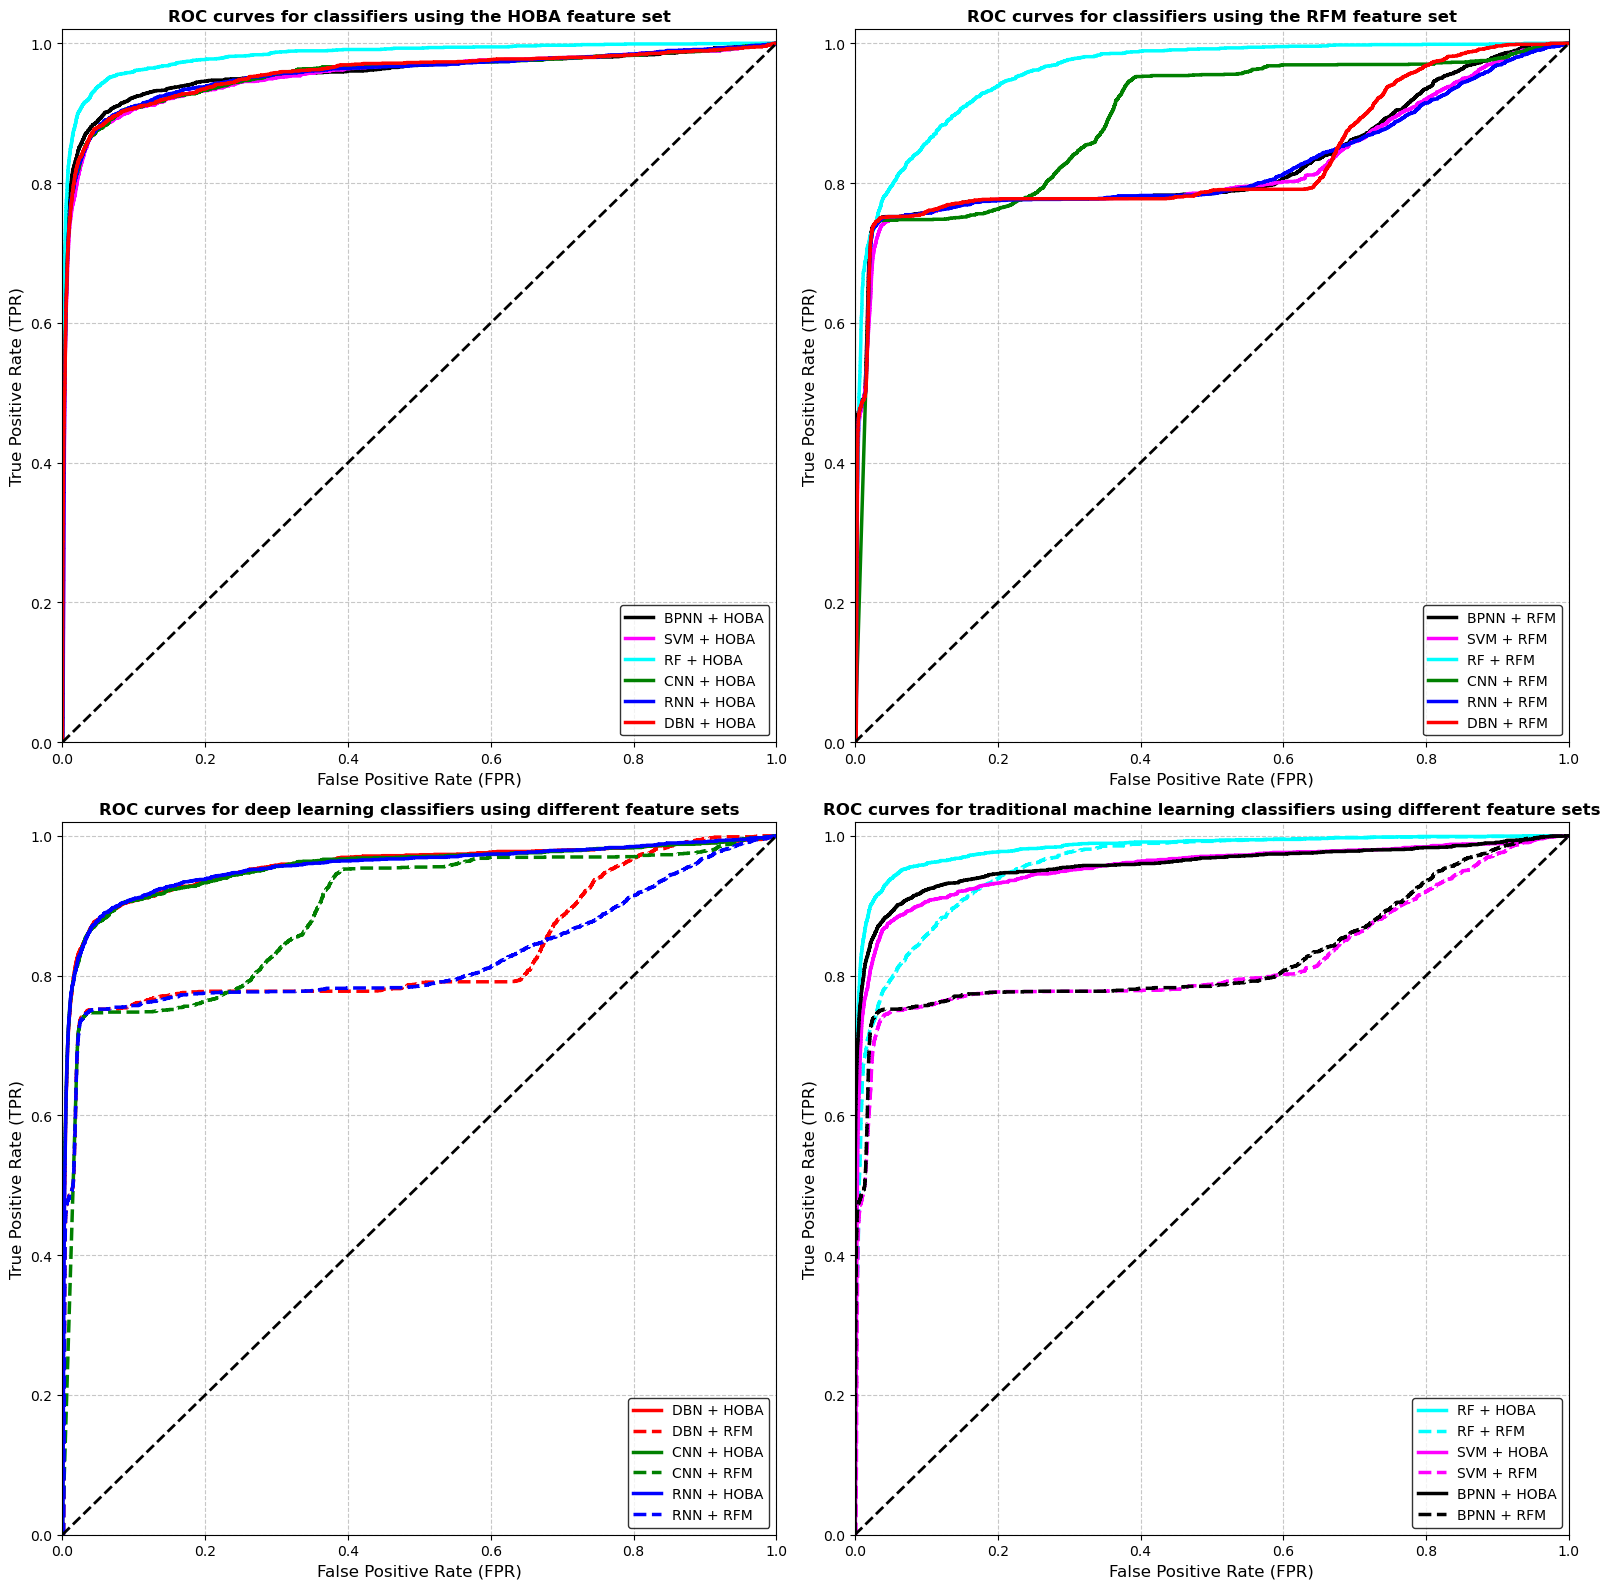

Success! The image (now including the red DBN line) is saved as 'Final_ROC_Curves_Complete.png'.


In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

print("Patching the Deep Belief Network (DBN) into the pipeline...")

# --- 1. Define DBN Classes ---
class RBM(nn.Module):
    def __init__(self, visible_dim, hidden_dim):
        super(RBM, self).__init__()
        self.W = nn.Parameter(torch.randn(hidden_dim, visible_dim) * 0.01)
        self.h_bias = nn.Parameter(torch.zeros(hidden_dim))
        self.v_bias = nn.Parameter(torch.zeros(visible_dim))

    def sample_h(self, v):
        h_prob = torch.sigmoid(F.linear(v, self.W, self.h_bias))
        return h_prob, torch.bernoulli(h_prob)

    def sample_v(self, h):
        v_prob = torch.sigmoid(F.linear(h, self.W.t(), self.v_bias))
        return v_prob, torch.bernoulli(v_prob)

    def contrastive_divergence(self, v_pos, lr=0.01):
        h_pos_prob, h_pos_sample = self.sample_h(v_pos)
        v_neg_prob, v_neg_sample = self.sample_v(h_pos_sample)
        h_neg_prob, _ = self.sample_h(v_neg_prob)

        pos_grad = torch.matmul(h_pos_prob.t(), v_pos)
        neg_grad = torch.matmul(h_neg_prob.t(), v_neg_prob)
        batch_size = v_pos.size(0)

        self.W.data += lr * (pos_grad - neg_grad) / batch_size
        self.v_bias.data += lr * torch.mean(v_pos - v_neg_prob, dim=0)
        self.h_bias.data += lr * torch.mean(h_pos_prob - h_neg_prob, dim=0)

class DeepSupervisedDBN(nn.Module):
    def __init__(self, rbm1, rbm2):
        super(DeepSupervisedDBN, self).__init__()
        self.layer1 = nn.Linear(rbm1.W.shape[1], rbm1.W.shape[0])
        self.layer1.weight.data = rbm1.W.clone()
        self.layer1.bias.data = rbm1.h_bias.clone()
        self.layer2 = nn.Linear(rbm2.W.shape[1], rbm2.W.shape[0])
        self.layer2.weight.data = rbm2.W.clone()
        self.layer2.bias.data = rbm2.h_bias.clone()
        self.output_layer = nn.Linear(rbm2.W.shape[0], 1)

    def forward(self, x):
        x = torch.sigmoid(self.layer1(x))
        x = torch.sigmoid(self.layer2(x))
        return self.output_layer(x)

# Setup common loss
pos_weight_value = (len(y_train) - sum(y_train)) / sum(y_train)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.FloatTensor([pos_weight_value]))

# --- 2. Train DBN on 77 HOBA Features ---
print("Training DBN on HOBA Features...")
X_train_hoba_tensor = torch.FloatTensor(X_train_scaled)
X_test_hoba_tensor = torch.FloatTensor(X_test_scaled)
train_loader_hoba = DataLoader(TensorDataset(X_train_hoba_tensor, torch.LongTensor(y_train).float()), batch_size=256, shuffle=True)

rbm1_hoba = RBM(X_train_hoba_tensor.shape[1], 64)
for _ in range(3):
    for batch in train_loader_hoba: rbm1_hoba.contrastive_divergence(batch[0])

with torch.no_grad(): h1_hoba, _ = rbm1_hoba.sample_h(X_train_hoba_tensor)
train_loader_h1_hoba = DataLoader(TensorDataset(h1_hoba), batch_size=256, shuffle=True)

rbm2_hoba = RBM(64, 32)
for _ in range(3):
    for batch in train_loader_h1_hoba: rbm2_hoba.contrastive_divergence(batch[0])

dbn_hoba = DeepSupervisedDBN(rbm1_hoba, rbm2_hoba)
opt_dbn_h = optim.Adam(dbn_hoba.parameters(), lr=0.005)
for _ in range(4):
    for b_x, b_y in train_loader_hoba:
        opt_dbn_h.zero_grad()
        loss = criterion(dbn_hoba(b_x).squeeze(), b_y)
        loss.backward()
        opt_dbn_h.step()

# --- 3. Train DBN on 4 RFM Features ---
print("Training DBN on RFM Features...")
X_train_rfm_tensor = torch.FloatTensor(X_train_rfm_scaled)
X_test_rfm_tensor = torch.FloatTensor(X_test_rfm_scaled)
train_loader_rfm = DataLoader(TensorDataset(X_train_rfm_tensor, torch.LongTensor(y_train).float()), batch_size=256, shuffle=True)

rbm1_rfm = RBM(X_train_rfm_tensor.shape[1], 32)
for _ in range(3):
    for batch in train_loader_rfm: rbm1_rfm.contrastive_divergence(batch[0])

with torch.no_grad(): h1_rfm, _ = rbm1_rfm.sample_h(X_train_rfm_tensor)
train_loader_h1_rfm = DataLoader(TensorDataset(h1_rfm), batch_size=256, shuffle=True)

rbm2_rfm = RBM(32, 16)
for _ in range(3):
    for batch in train_loader_h1_rfm: rbm2_rfm.contrastive_divergence(batch[0])

dbn_rfm = DeepSupervisedDBN(rbm1_rfm, rbm2_rfm)
opt_dbn_r = optim.Adam(dbn_rfm.parameters(), lr=0.005)
for _ in range(4):
    for b_x, b_y in train_loader_rfm:
        opt_dbn_r.zero_grad()
        loss = criterion(dbn_rfm(b_x).squeeze(), b_y)
        loss.backward()
        opt_dbn_r.step()

# --- 4. Inject Predictions into Dictionaries ---
print("Updating Prediction Dictionaries...")
dbn_hoba.eval()
dbn_rfm.eval()
with torch.no_grad():
    hoba_predictions['DBN'] = torch.sigmoid(dbn_hoba(X_test_hoba_tensor).squeeze()).numpy()
    rfm_predictions['DBN'] = torch.sigmoid(dbn_rfm(X_test_rfm_tensor).squeeze()).numpy()

# --- 5. Draw Final Complete Plots ---
print("Drawing Final ROC Curves with DBN...")
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
plt.style.use('default')

colors = {'DBN': 'red', 'CNN': 'green', 'RNN': 'blue', 'RF': 'cyan', 'SVM': 'magenta', 'BPNN': 'black'}

def plot_roc(ax, y_true, y_pred, label, color, linestyle='-'):
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    ax.plot(fpr, tpr, label=label, color=color, linestyle=linestyle, linewidth=2.5)

# Top Left: HOBA
axes[0, 0].set_title('ROC curves for classifiers using the HOBA feature set', fontweight='bold')
for name, preds in hoba_predictions.items():
    plot_roc(axes[0, 0], y_test, preds, f"{name} + HOBA", colors.get(name, 'orange'))

# Top Right: RFM
axes[0, 1].set_title('ROC curves for classifiers using the RFM feature set', fontweight='bold')
for name, preds in rfm_predictions.items():
    plot_roc(axes[0, 1], y_test, preds, f"{name} + RFM", colors.get(name, 'orange'))

# Bottom Left: Deep Learning Models
axes[1, 0].set_title('ROC curves for deep learning classifiers using different feature sets', fontweight='bold')
for name in ['DBN', 'CNN', 'RNN']:
    if name in hoba_predictions: plot_roc(axes[1, 0], y_test, hoba_predictions[name], f"{name} + HOBA", colors.get(name), '-')
    if name in rfm_predictions: plot_roc(axes[1, 0], y_test, rfm_predictions[name], f"{name} + RFM", colors.get(name), '--')

# Bottom Right: Traditional ML Models
axes[1, 1].set_title('ROC curves for traditional machine learning classifiers using different feature sets', fontweight='bold')
for name in ['RF', 'SVM', 'BPNN']:
    if name in hoba_predictions: plot_roc(axes[1, 1], y_test, hoba_predictions[name], f"{name} + HOBA", colors.get(name), '-')
    if name in rfm_predictions: plot_roc(axes[1, 1], y_test, rfm_predictions[name], f"{name} + RFM", colors.get(name), '--')

# Apply Formatting
for ax in axes.flat:
    ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=2)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.02])
    ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
    ax.set_ylabel('True Positive Rate (TPR)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc="lower right", fontsize=10, frameon=True, edgecolor='black')

plt.tight_layout()
plt.savefig('Final_ROC_Curves_Complete.png', dpi=300, bbox_inches='tight')
plt.show()
print("Success! The image (now including the red DBN line) is saved as 'Final_ROC_Curves_Complete.png'.")